In [1]:
!pip install ultralytics opencv-python matplotlib seaborn pandas numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00a 0:00:01


In [9]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, EfficientNetB0, EfficientNetB4
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate, Input

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_curve, auc,
                             matthews_corrcoef, cohen_kappa_score)
from sklearn.metrics import roc_auc_score

# Visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

print("✅ All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")

E0000 00:00:1776362832.039344      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776362832.118643      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776362832.705997      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776362832.706033      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776362832.706037      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776362832.706040      55 computation_placer.cc:177] computation placer already registered. Please check linka

✅ All libraries imported successfully
TensorFlow version: 2.19.0
OpenCV version: 4.13.0


In [3]:
# Set your dataset path here
DATASET_PATH = "/kaggle/input/datasets/mahmoudeldebase/egyptian-cars-plates/EALPR Vechicles dataset"
IMAGES_DIR = os.path.join(DATASET_PATH, "Vehicles")
LABELS_DIR = os.path.join(DATASET_PATH, "Vehicles Labeling")

# Verify folders exist
assert os.path.exists(IMAGES_DIR), f"Images folder not found at {IMAGES_DIR}"
assert os.path.exists(LABELS_DIR), f"Labels folder not found at {LABELS_DIR}"

print(f"✅ Images found: {len(os.listdir(IMAGES_DIR))}")
print(f"✅ Labels found: {len(os.listdir(LABELS_DIR))}")

✅ Images found: 2087
✅ Labels found: 2088


In [4]:
def show_sample(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    with open(label_path, 'r') as f:
        labels = f.readlines()
    
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    ax = plt.gca()
    
    for label in labels:
        parts = label.strip().split()
        if len(parts) == 5:
            class_id, x_c, y_c, box_w, box_h = map(float, parts)
            x1 = (x_c - box_w/2) * w
            y1 = (y_c - box_h/2) * h
            x2 = (x_c + box_w/2) * w
            y2 = (y_c + box_h/2) * h
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                 linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            plt.text(x1, y1-5, f'Plate', color='red', fontsize=12)
    
    plt.axis('off')
    plt.title(f"Sample: {os.path.basename(img_path)}")
    plt.show()

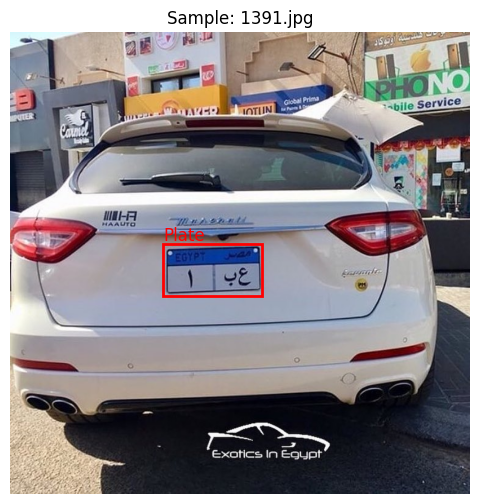

In [5]:
sample_img = random.choice(os.listdir(IMAGES_DIR))
sample_img_path = os.path.join(IMAGES_DIR, sample_img)
sample_label_path = os.path.join(LABELS_DIR, sample_img.replace('.jpg', '.txt').replace('.png', '.txt'))

if os.path.exists(sample_label_path):
    show_sample(sample_img_path, sample_label_path)
else:
    print(f"No label for {sample_img}")

In [ ]:
# ============================================================
# PRE-PROCESSING PHASE — Step 1: Image Enhancement
# Techniques: Histogram Equalization, CLAHE, Contrast
# Stretching, Gaussian Noise Removal, Bilateral Filtering,
# Sharpening, Gamma Correction
# ============================================================
from scipy.ndimage import gaussian_filter

def apply_image_enhancements(img_bgr):
    """
    Apply a full suite of image enhancement techniques.
    Input : BGR image (uint8)
    Output: dict of enhanced images (RGB, uint8)
    """
    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    enhanced  = {}

    # 1. Original
    enhanced['Original'] = img_rgb

    # 2. Histogram Equalization (on Y channel of YCrCb)
    img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    img_ycrcb[:, :, 0] = cv2.equalizeHist(img_ycrcb[:, :, 0])
    enhanced['Histogram Equalization'] = cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2RGB)

    # 3. CLAHE – Contrast Limited Adaptive Histogram Equalization
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_lab   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
    enhanced['CLAHE'] = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)

    # 4. Contrast Stretching (min-max normalisation per channel)
    stretched = img_rgb.astype('float32')
    for c in range(3):
        mn, mx = stretched[:, :, c].min(), stretched[:, :, c].max()
        if mx > mn:
            stretched[:, :, c] = (stretched[:, :, c] - mn) / (mx - mn) * 255
    enhanced['Contrast Stretching'] = stretched.astype('uint8')

    # 5. Gaussian Noise Removal
    enhanced['Gaussian Denoising'] = cv2.GaussianBlur(img_rgb, (5, 5), 0)

    # 6. Bilateral Filter (edge-preserving smoothing)
    enhanced['Bilateral Filter'] = cv2.bilateralFilter(img_rgb, d=9, sigmaColor=75, sigmaSpace=75)

    # 7. Median Filter (impulse / salt-and-pepper noise removal)
    enhanced['Median Filter'] = cv2.medianBlur(img_rgb, 5)

    # 8. Unsharp Masking / Sharpening
    blurred = cv2.GaussianBlur(img_rgb, (0, 0), 3)
    enhanced['Sharpening'] = cv2.addWeighted(img_rgb, 1.5, blurred, -0.5, 0)

    # 9. Gamma Correction (gamma = 1.5)
    inv_gamma = 1.0 / 1.5
    lut = (np.arange(256) / 255.0) ** inv_gamma * 255
    lut = np.clip(lut, 0, 255).astype('uint8')
    enhanced['Gamma Correction'] = cv2.LUT(img_rgb, lut)

    return enhanced


def visualize_enhancements(img_path, save_path='enhancement_comparison.png'):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f'Could not read {img_path}'); return
    enhanced = apply_image_enhancements(img_bgr)

    n     = len(enhanced)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
    axes = axes.ravel()

    for idx, (title, img) in enumerate(enhanced.items()):
        axes[idx].imshow(img)
        axes[idx].set_title(title, fontsize=13, fontweight='bold')
        axes[idx].axis('off')
    for idx in range(n, len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Image Enhancement Techniques', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\u2705 Enhancement comparison saved to {save_path}')


# Also plot histograms before / after CLAHE
def plot_histograms(img_path, save_path='histograms.png'):
    img_bgr  = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].imshow(img_gray, cmap='gray'); axes[0, 0].set_title('Original Grayscale'); axes[0, 0].axis('off')
    axes[0, 1].hist(img_gray.ravel(), 256, [0, 256], color='steelblue', alpha=0.8)
    axes[0, 1].set_title('Histogram – Original'); axes[0, 1].set_xlabel('Pixel Value'); axes[0, 1].set_ylabel('Count')

    axes[1, 0].imshow(img_clahe, cmap='gray'); axes[1, 0].set_title('After CLAHE'); axes[1, 0].axis('off')
    axes[1, 1].hist(img_clahe.ravel(), 256, [0, 256], color='tomato', alpha=0.8)
    axes[1, 1].set_title('Histogram – After CLAHE'); axes[1, 1].set_xlabel('Pixel Value'); axes[1, 1].set_ylabel('Count')

    plt.suptitle('Histogram Enhancement Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Run on one sample image
sample_img_files = [f for f in os.listdir(IMAGES_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))]
demo_path = os.path.join(IMAGES_DIR, sample_img_files[0])
visualize_enhancements(demo_path)
plot_histograms(demo_path)
print('\u2705 Pre-processing Step 1 complete: Image Enhancements')


In [ ]:
# ============================================================
# PRE-PROCESSING PHASE — Step 2: Frequency Domain Analysis
# Techniques: DFT/FFT magnitude spectrum, Low-pass filter,
# High-pass filter, Band-pass filter, Ideal & Gaussian filters
# ============================================================

def compute_fft(img_gray):
    """Compute 2-D FFT and return shifted magnitude spectrum."""
    f      = np.fft.fft2(img_gray.astype('float32'))
    fshift = np.fft.fftshift(f)
    mag    = 20 * np.log1p(np.abs(fshift))
    return fshift, mag


def ideal_filter(shape, radius, filter_type='low'):
    """Ideal low-pass or high-pass filter mask."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    dist = np.sqrt((Y - crow)**2 + (X - ccol)**2)
    if filter_type == 'low':
        mask = (dist <= radius).astype('float32')
    else:  # high
        mask = (dist > radius).astype('float32')
    return mask


def gaussian_filter_freq(shape, cutoff, filter_type='low'):
    """Gaussian low-pass or high-pass filter mask."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    dist2 = (Y - crow)**2 + (X - ccol)**2
    glp   = np.exp(-dist2 / (2 * cutoff**2)).astype('float32')
    return glp if filter_type == 'low' else 1 - glp


def apply_freq_filter(img_gray, mask):
    """Apply a frequency-domain mask and return the reconstructed image."""
    fshift     = np.fft.fftshift(np.fft.fft2(img_gray.astype('float32')))
    filtered   = fshift * mask
    ishift     = np.fft.ifftshift(filtered)
    img_back   = np.abs(np.fft.ifft2(ishift))
    img_back   = np.clip(img_back, 0, 255).astype('uint8')
    return img_back


def visualize_frequency_domain(img_path, save_path='frequency_domain.png'):
    img_bgr  = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w     = img_gray.shape

    _, mag_orig = compute_fft(img_gray)

    # Build filter masks
    ideal_lp  = ideal_filter((h, w), radius=30, filter_type='low')
    ideal_hp  = ideal_filter((h, w), radius=30, filter_type='high')
    gauss_lp  = gaussian_filter_freq((h, w), cutoff=30, filter_type='low')
    gauss_hp  = gaussian_filter_freq((h, w), cutoff=30, filter_type='high')
    # Band-pass = gaussian LP – gaussian HP with tighter cutoff
    band_pass = gaussian_filter_freq((h, w), cutoff=60, filter_type='low') - \
                gaussian_filter_freq((h, w), cutoff=10, filter_type='low')
    band_pass = np.clip(band_pass, 0, 1)

    reconstructed = {
        'Original':           img_gray,
        'FFT Magnitude':      mag_orig.astype('uint8'),
        'Ideal LP (r=30)':    apply_freq_filter(img_gray, ideal_lp),
        'Ideal HP (r=30)':    apply_freq_filter(img_gray, ideal_hp),
        'Gaussian LP (σ=30)': apply_freq_filter(img_gray, gauss_lp),
        'Gaussian HP (σ=30)': apply_freq_filter(img_gray, gauss_hp),
        'Band-Pass Filter':   apply_freq_filter(img_gray, band_pass),
    }

    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.ravel()
    for idx, (title, img) in enumerate(reconstructed.items()):
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(title, fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    axes[len(reconstructed)].axis('off')

    plt.suptitle('Frequency Domain Filters (DFT / FFT)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\u2705 Frequency domain visualisation saved to {save_path}')


visualize_frequency_domain(demo_path)
print('\u2705 Pre-processing Step 2 complete: Frequency Domain Filtering')


In [ ]:
# ============================================================
# PRE-PROCESSING PHASE — Step 3: Apply pipeline to full dataset
# Default pipeline: CLAHE → Bilateral filter → Sharpening
# ============================================================

def preprocess_image(img_bgr, target_size=(224, 224)):
    """
    Full pre-processing pipeline applied to every image before
    feature extraction:
      1. Resize
      2. CLAHE on LAB lightness channel
      3. Bilateral filter (edge-preserving noise reduction)
      4. Unsharp masking (sharpening)
    Returns RGB uint8 image.
    """
    # Resize
    img = cv2.resize(img_bgr, target_size)

    # CLAHE
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
    img = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)

    # Bilateral filter
    img = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

    # Sharpening
    blurred = cv2.GaussianBlur(img, (0, 0), 3)
    img     = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def load_images_preprocessed(images_dir, labels_dir,
                              img_size=(224, 224), max_samples=2000):
    """Load + pre-process images and build classification labels."""
    image_files = sorted([
        f for f in os.listdir(images_dir)
        if f.endswith(('.jpg', '.png', '.jpeg'))
    ])
    if max_samples:
        image_files = image_files[:max_samples]

    images, labels, metadata = [], [], []

    for img_file in tqdm(image_files, desc='Loading + Pre-processing'):
        img_bgr = cv2.imread(os.path.join(images_dir, img_file))
        if img_bgr is None:
            continue

        img_proc = preprocess_image(img_bgr, target_size=img_size)
        images.append(img_proc)

        label_file = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(labels_dir, label_file)
        num_plates, avg_box_area, avg_aspect_ratio = 0, 0.0, 0.0

        if os.path.exists(label_path):
            with open(label_path) as f:
                label_data = f.readlines()
            num_plates = len(label_data)
            areas, aspects = [], []
            for lbl in label_data:
                parts = lbl.strip().split()
                if len(parts) == 5:
                    _, xc, yc, bw, bh = map(float, parts)
                    areas.append(bw * bh)
                    aspects.append(bw / bh if bh > 0 else 0)
            if areas:
                avg_box_area     = float(np.mean(areas))
                avg_aspect_ratio = float(np.mean(aspects))
            label_class = 2 if avg_box_area > 0.05 else (1 if avg_box_area > 0.02 else 0)
        else:
            label_class = 0

        labels.append(label_class)
        metadata.append({
            'filename': img_file, 'num_plates': num_plates,
            'avg_box_area': avg_box_area, 'avg_aspect_ratio': avg_aspect_ratio
        })

    return np.array(images), np.array(labels), metadata


# Load the pre-processed dataset (replaces the raw X_images)
X_images, y_labels, metadata = load_images_preprocessed(
    IMAGES_DIR, LABELS_DIR, max_samples=2000
)
print(f'\u2705 Pre-processed dataset: {X_images.shape}')
print(f'\ud83d\udcca Class distribution: {np.bincount(y_labels)}')


In [ ]:
# ============================================================
# SEGMENTATION & FEATURE EXTRACTION — Classical Methods
# Techniques: Otsu thresholding, Canny edges, Contour-based
# ROI detection, HOG descriptors, LBP texture features,
# Color histogram features
# ============================================================
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage import exposure

# ── Segmentation visualisation ──────────────────────────────────────────────
def segment_image(img_rgb, save_prefix='segmentation'):
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    img_bgr  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    # 1. Otsu's Thresholding
    _, otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 2. Adaptive Thresholding
    adaptive = cv2.adaptiveThreshold(
        img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )

    # 3. Canny Edge Detection
    canny = cv2.Canny(img_gray, 50, 150)

    # 4. Morphological operations to refine edges
    kernel  = np.ones((3, 3), np.uint8)
    morph   = cv2.morphologyEx(otsu, cv2.MORPH_CLOSE, kernel)

    # 5. Contour detection – draw bounding boxes around plate candidates
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_contours = img_rgb.copy()
    plate_candidates = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect = w / h if h > 0 else 0
        area   = cv2.contourArea(cnt)
        # Plate heuristic: wide rectangles with reasonable area
        if 1.5 < aspect < 6.0 and area > 300:
            plate_candidates.append((x, y, w, h))
            cv2.rectangle(img_contours, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    panels = [
        ('Original',             img_rgb,       'viridis'),
        ("Otsu's Threshold",    otsu,           'gray'),
        ('Adaptive Threshold',  adaptive,       'gray'),
        ('Canny Edges',         canny,          'gray'),
        ('Morphological Close', morph,          'gray'),
        (f'Plate Candidates ({len(plate_candidates)})', img_contours, 'viridis'),
    ]
    for ax, (title, img, cmap) in zip(axes, panels):
        ax.imshow(img, cmap=cmap if img.ndim == 2 else None)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.suptitle('Image Segmentation Methods', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Classical Feature Extraction ────────────────────────────────────────────
def extract_classical_features(img_rgb):
    """
    Extract hand-crafted features from one image:
      - HOG (Histogram of Oriented Gradients)
      - LBP (Local Binary Patterns) histogram
      - Colour histogram (HSV)
    Returns a 1-D feature vector.
    """
    img_gray = rgb2gray(img_rgb)

    # HOG features
    hog_feats, _ = hog(
        img_gray, orientations=9, pixels_per_cell=(16, 16),
        cells_per_block=(2, 2), visualize=True
    )

    # LBP histogram (radius=3, 24 sampling points)
    lbp      = local_binary_pattern(img_gray, P=24, R=3, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=26, range=(0, 26), density=True)

    # Colour histogram (HSV, 16 bins per channel)
    img_hsv  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    col_hist = []
    for c in range(3):
        hist, _ = np.histogram(img_hsv[:, :, c], bins=16, range=(0, 256), density=True)
        col_hist.append(hist)
    col_hist = np.concatenate(col_hist)

    return np.concatenate([hog_feats, lbp_hist, col_hist])


def visualize_hog_lbp(img_rgb, save_path='hog_lbp.png'):
    img_gray = rgb2gray(img_rgb)

    _, hog_img = hog(
        img_gray, orientations=9, pixels_per_cell=(16, 16),
        cells_per_block=(2, 2), visualize=True
    )
    hog_img_resc = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    lbp     = local_binary_pattern(img_gray, P=24, R=3, method='uniform')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_rgb);           axes[0].set_title('Original', fontweight='bold')
    axes[1].imshow(hog_img_resc, cmap='gray'); axes[1].set_title('HOG Descriptor', fontweight='bold')
    axes[2].imshow(lbp, cmap='gray');  axes[2].set_title('LBP Texture', fontweight='bold')
    for ax in axes: ax.axis('off')
    plt.suptitle('Feature Extraction: HOG & LBP', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Demo on one sample
demo_img_rgb = X_images[0]
segment_image(demo_img_rgb)
visualize_hog_lbp(demo_img_rgb)

# Extract classical features for ALL images
print('Extracting classical features for all images...')
classical_features = np.array([
    extract_classical_features(img) for img in tqdm(X_images, desc='Classical features')
])
print(f'\u2705 Classical features shape: {classical_features.shape}')


In [11]:
class FeatureExtractor:
    def __init__(self):
        self.extractors = {}
        self.models = {}
        
    def load_model(self, model_name, input_shape=(224, 224, 3)):
        """Load pretrained CNN model without top layers"""
        if model_name == 'VGG16':
            base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
        elif model_name == 'VGG19':
            base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
        elif model_name == 'ResNet50':
            base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
        elif model_name == 'EfficientNetB0':
            base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
        elif model_name == 'EfficientNetB4':
            base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=input_shape)
        else:
            raise ValueError(f"Unknown model: {model_name}")
        
        # Add global pooling and dense layers
        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dense(256, activation='relu')(x)
        x = Dropout(0.3)(x)
        features = Dense(128, activation='relu')(x)
        
        model = Model(inputs=base_model.input, outputs=features)
        
        # Freeze base model layers
        for layer in base_model.layers:
            layer.trainable = False
        
        return model
    
    def extract_features(self, images, model_name, batch_size=32):
        """Extract features from images using specified model"""
        print(f"Extracting features using {model_name}...")
        
        if model_name not in self.models:
            self.models[model_name] = self.load_model(model_name)
        
        model = self.models[model_name]
        
        # Preprocess images according to model requirements
        if model_name in ['VGG16', 'VGG19']:
            preprocessed = tf.keras.applications.vgg16.preprocess_input(images.astype('float32'))
        elif model_name == 'ResNet50':
            preprocessed = tf.keras.applications.resnet50.preprocess_input(images.astype('float32'))
        else:  # EfficientNet
            preprocessed = tf.keras.applications.efficientnet.preprocess_input(images.astype('float32'))
        
        # Extract features
        features = model.predict(preprocessed, batch_size=batch_size, verbose=0)
        return features

# Initialize extractor
extractor = FeatureExtractor()

# Extract features from all architectures
architectures = ['VGG16', 'VGG19', 'ResNet50', 'EfficientNetB0', 'EfficientNetB4']
features_dict = {}

for arch in architectures:
    features_dict[arch] = extractor.extract_features(X_images, arch)
    print(f"✅ {arch}: {features_dict[arch].shape}")

Extracting features using VGG16...


I0000 00:00:1776362975.926696      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11119 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1776362982.579218     202 service.cc:152] XLA service 0x7f5a3c00ae20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776362982.579255     202 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776362982.769493     202 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776362997.511405     202 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


✅ VGG16: (2000, 128)
Extracting features using VGG19...
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ VGG19: (2000, 128)
Extracting features using ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ ResNet50: (2000, 128)
Extracting features using EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB0: (2000, 128)
Extracting features using EfficientNetB4...
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB4: (2000, 128)


In [12]:
def create_feature_engineering_features(metadata):
    """Create hand-crafted features from metadata"""
    features = []
    
    for meta in metadata:
        # Statistical features
        num_plates = meta['num_plates']
        avg_area = meta['avg_box_area']
        avg_aspect = meta['avg_aspect_ratio']
        
        # Derived features
        area_category = 1 if avg_area > 0.03 else 0
        has_plate = 1 if num_plates > 0 else 0
        is_wide_plate = 1 if avg_aspect > 2.0 else 0
        
        # Image name features (if contains plate info)
        filename = meta['filename'].lower()
        has_letter = 1 if any(c.isalpha() for c in filename) else 0
        
        feature_vector = [
            num_plates,
            avg_area,
            avg_aspect,
            area_category,
            has_plate,
            is_wide_plate,
            has_letter
        ]
        features.append(feature_vector)
    
    return np.array(features)

# Create engineering features
engineering_features = create_feature_engineering_features(metadata)
print(f"✅ Engineering features shape: {engineering_features.shape}")

✅ Engineering features shape: (2000, 7)


In [ ]:
# ============================================================
# CLUSTERING ANALYSIS (unsupervised)
# Techniques: K-Means, Agglomerative Hierarchical Clustering,
# DBSCAN, PCA for visualisation
# ============================================================
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler as SS

# Use PCA-reduced classical features for clustering (faster + less noise)
scaler_cl = SS()
X_cl      = scaler_cl.fit_transform(classical_features)

pca_cl    = PCA(n_components=50, random_state=42)
X_pca     = pca_cl.fit_transform(X_cl)
print(f'\u2705 PCA explained variance (50 components): {pca_cl.explained_variance_ratio_.sum():.2%}')

# 2-D for visualisation
pca2      = PCA(n_components=2, random_state=42)
X_2d      = pca2.fit_transform(X_cl)

# ── K-Means ──────────────────────────────────────────────────────────────────
kmeans     = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels  = kmeans.fit_predict(X_pca)
km_sil     = silhouette_score(X_pca, km_labels)
km_db      = davies_bouldin_score(X_pca, km_labels)
km_ari     = adjusted_rand_score(y_labels, km_labels)
print(f'K-Means   → Silhouette: {km_sil:.4f} | DB Index: {km_db:.4f} | ARI: {km_ari:.4f}')

# Elbow plot for optimal K
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_pca)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (K)'); plt.ylabel('Inertia')
plt.title('K-Means Elbow Plot', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Agglomerative Clustering ─────────────────────────────────────────────────
agg        = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_pca)
agg_sil    = silhouette_score(X_pca, agg_labels)
agg_ari    = adjusted_rand_score(y_labels, agg_labels)
print(f'Agglomerative → Silhouette: {agg_sil:.4f} | ARI: {agg_ari:.4f}')

# ── DBSCAN ────────────────────────────────────────────────────────────────────
dbscan      = DBSCAN(eps=3.0, min_samples=5)
db_labels   = dbscan.fit_predict(X_pca)
n_clusters_ = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_    = list(db_labels).count(-1)
print(f'DBSCAN    → Clusters: {n_clusters_} | Noise points: {n_noise_}')
if n_clusters_ > 1:
    mask_valid = db_labels != -1
    db_sil     = silhouette_score(X_pca[mask_valid], db_labels[mask_valid])
    print(f'           Silhouette (excl. noise): {db_sil:.4f}')

# ── Clustering visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ['Small Plate', 'Medium Plate', 'Large Plate']
cmap_c = plt.cm.Set1

for ax, (title, cl) in zip(axes, [
        ('K-Means (k=3)', km_labels),
        ('Agglomerative (ward, k=3)', agg_labels),
        ('True Labels', y_labels)]):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=cl, cmap=cmap_c, s=10, alpha=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('PC-1'); ax.set_ylabel('PC-2')
    plt.colorbar(sc, ax=ax)

plt.suptitle('Clustering Analysis – PCA 2-D Projection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Clustering analysis complete')


In [ ]:
# ============================================================
# Merge classical features with CNN features for downstream
# classifiers — this cell replaces the old engineering-only merge
# ============================================================
print('Classical features shape:', classical_features.shape)
print('CNN features (best arch) shape:', features_dict[best_architecture].shape)

# Normalise classical features before merging
scaler_classical = SS()
classical_norm   = scaler_classical.fit_transform(classical_features)

# Final merged feature set = CNN + classical + metadata engineering
merged_features_full = np.hstack([
    features_dict[best_architecture],
    classical_norm,
    engineering_features
])
print(f'\u2705 Final merged feature set shape: {merged_features_full.shape}')

# Update global merged_features for downstream classifiers
merged_features = merged_features_full
print('\u2705 merged_features updated — classifiers will use CNN + HOG/LBP/Colour + metadata')


In [13]:
def merge_features(features_dict, engineering_features, arch_names):
    """Find best performing architecture and merge with engineering features"""
    
    # We'll evaluate each architecture's separability
    from sklearn.decomposition import PCA
    from sklearn.cluster import KMeans
    
    best_arch = None
    best_score = -1
    
    for arch in arch_names:
        # Calculate cluster separability
        features = features_dict[arch]
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(features)
        
        # Calculate silhouette score
        from sklearn.metrics import silhouette_score
        sil_score = silhouette_score(features, clusters)
        
        if sil_score > best_score:
            best_score = sil_score
            best_arch = arch
    
    print(f"🏆 Best architecture: {best_arch} (Silhouette Score: {best_score:.4f})")
    
    # Merge best features with engineering features
    best_features = features_dict[best_arch]
    merged_features = np.hstack([best_features, engineering_features])
    
    print(f"✅ Merged features shape: {merged_features.shape}")
    
    return merged_features, best_arch

# Merge features
merged_features, best_architecture = merge_features(features_dict, engineering_features, architectures)

🏆 Best architecture: VGG16 (Silhouette Score: 0.1017)
✅ Merged features shape: (2000, 135)


In [14]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    merged_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 Training set: {X_train_scaled.shape}")
print(f"📊 Test set: {X_test_scaled.shape}")
print(f"🎯 Class distribution in train: {np.bincount(y_train)}")
print(f"🎯 Class distribution in test: {np.bincount(y_test)}")

📊 Training set: (1600, 135)
📊 Test set: (400, 135)
🎯 Class distribution in train: [1034  491   75]
🎯 Class distribution in test: [258 123  19]


In [15]:
# Define models to compare
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

# Additional models for ensemble
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Create ensemble models
voting_clf = VotingClassifier(
    estimators=[('rf', models['Random Forest']), 
                ('gb', models['Gradient Boosting']),
                ('svm', models['SVM (RBF)'])],
    voting='soft'
)
models['Voting Ensemble'] = voting_clf

print(f"✅ Total models to compare: {len(models)}")

✅ Total models to compare: 10


In [16]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Comprehensive model evaluation"""
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    # Basic metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Confusion matrix for specificity
    cm = confusion_matrix(y_test, y_pred)
    specificity_list = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_list.append(specificity)
    specificity = np.mean(specificity_list)
    
    # Kappa coefficient
    kappa = cohen_kappa_score(y_test, y_pred)
    
    # AUC-ROC (for multi-class)
    if y_pred_proba is not None:
        try:
            auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        except:
            auc_roc = 0
    else:
        auc_roc = 0
    
    # Matthews Correlation Coefficient
    mcc = matthews_corrcoef(y_test, y_pred)
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'AUC-ROC': auc_roc,
        'Kappa': kappa,
        'MCC': mcc,
        'Confusion Matrix': cm,
        'Model': model
    }

# Evaluate all models
results = {}
for model_name, model in tqdm(models.items(), desc="Evaluating models"):
    results[model_name] = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
    print(f"✅ {model_name}: Accuracy = {results[model_name]['Accuracy']:.4f}")

# Convert to DataFrame
results_df = pd.DataFrame({name: {k: v for k, v in res.items() if k not in ['Confusion Matrix', 'Model']} 
                           for name, res in results.items()}).T

Evaluating models:  10%|█         | 1/10 [00:01<00:09,  1.03s/it]

✅ Random Forest: Accuracy = 0.9600


Evaluating models:  20%|██        | 2/10 [00:11<00:53,  6.67s/it]

✅ Gradient Boosting: Accuracy = 0.9975


Evaluating models:  30%|███       | 3/10 [00:14<00:33,  4.84s/it]

...

✅ SVM (RBF): Accuracy = 0.8175


Evaluating models:  60%|██████    | 6/10 [00:18<00:08,  2.20s/it]

✅ SVM (Linear): Accuracy = 0.9350
✅ Logistic Regression: Accuracy = 0.9325
✅ K-Nearest Neighbors: Accuracy = 0.7525
✅ Decision Tree: Accuracy = 0.9975
✅ Naive Bayes: Accuracy = 0.4200


Evaluating models: 100%|██████████| 10/10 [00:31<00:00,  3.19s/it]

✅ Voting Ensemble: Accuracy = 0.9950


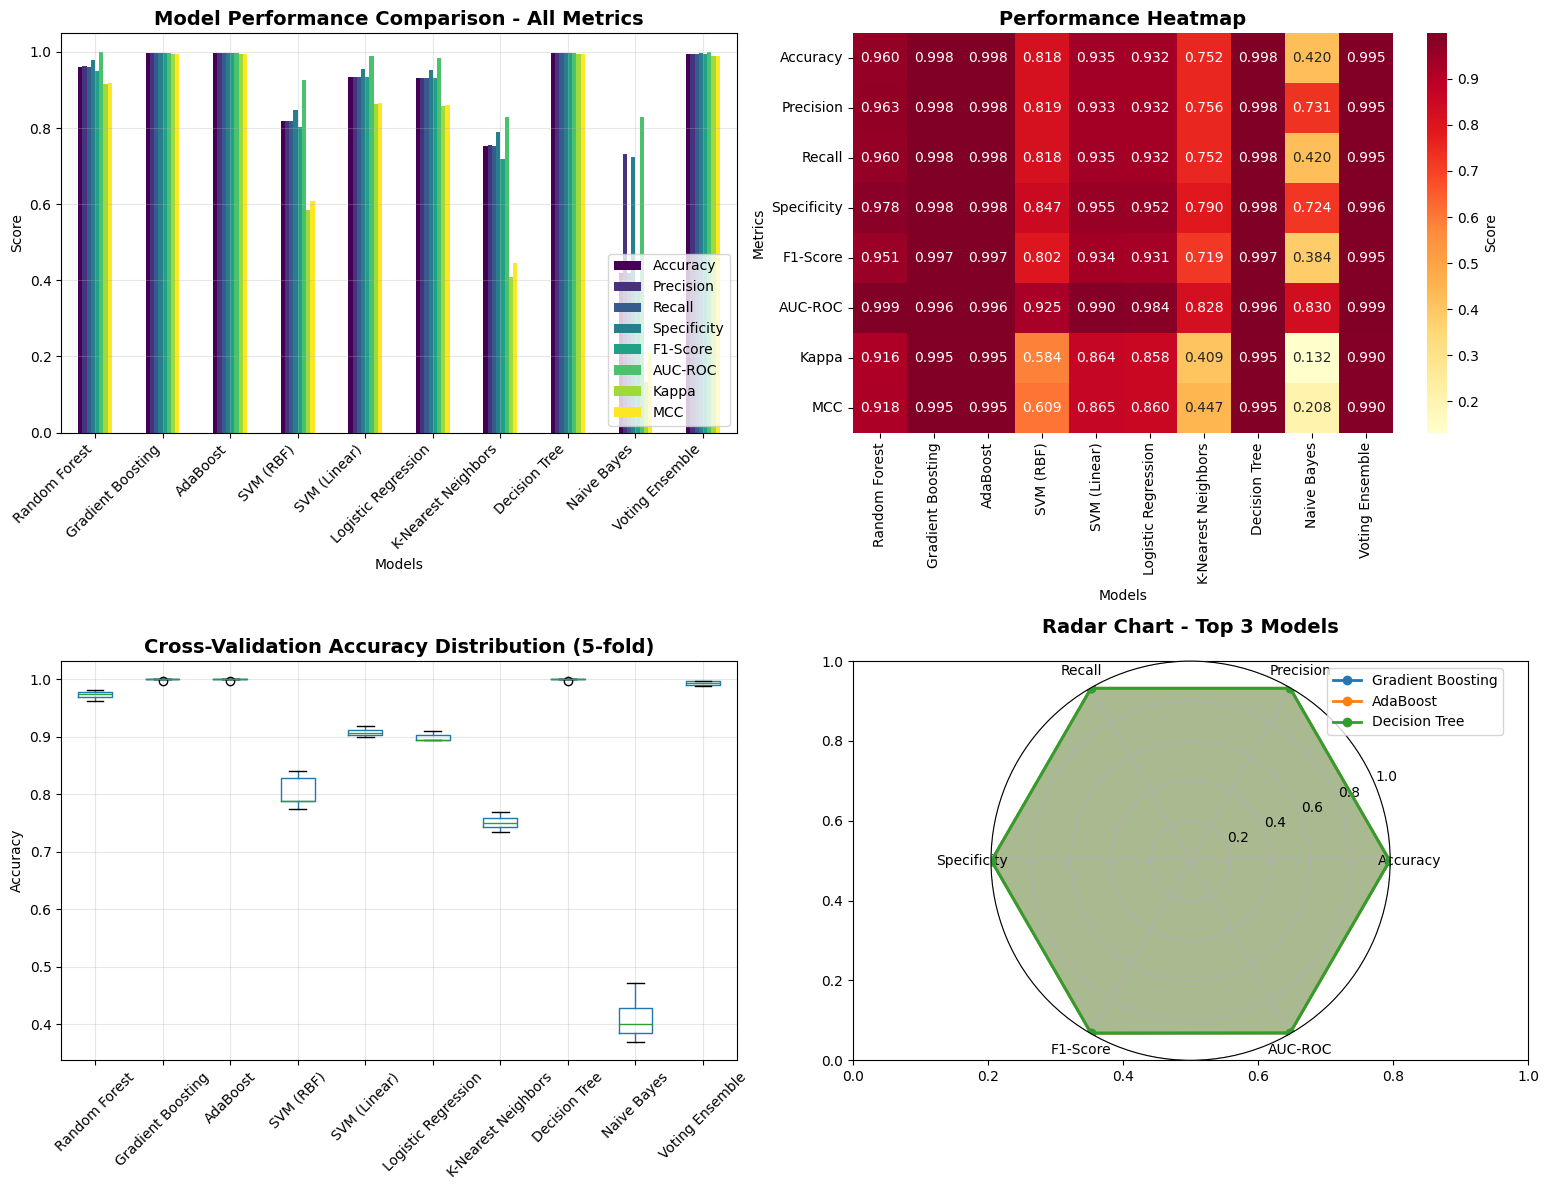

In [17]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar plot of all metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC-ROC', 'Kappa', 'MCC']
results_df[metrics_to_plot].plot(kind='bar', ax=axes[0, 0], colormap='viridis', legend=True)
axes[0, 0].set_title('Model Performance Comparison - All Metrics', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right')
axes[0, 0].legend(loc='lower right', bbox_to_anchor=(1.0, 0.0))
axes[0, 0].grid(True, alpha=0.3)

# 2. Heatmap of metrics
sns.heatmap(results_df[metrics_to_plot].T, annot=True, fmt='.3f', cmap='YlOrRd', 
            xticklabels=results_df.index, ax=axes[0, 1], cbar_kws={'label': 'Score'})
axes[0, 1].set_title('Performance Heatmap', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Metrics')

# 3. Accuracy comparison with confidence intervals (using cross-validation)
cv_scores = {}
for model_name, res in results.items():
    cv_scores_model = cross_val_score(res['Model'], X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores[model_name] = cv_scores_model

cv_df = pd.DataFrame(cv_scores)
cv_df.boxplot(ax=axes[1, 0], rot=45)
axes[1, 0].set_title('Cross-Validation Accuracy Distribution (5-fold)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].grid(True, alpha=0.3)

# 4. Radar chart for top 3 models
from sklearn.preprocessing import MinMaxScaler

top_3_models = results_df.nlargest(3, 'Accuracy').index.tolist()
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC-ROC']

angles = np.linspace(0, 2*np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]

ax = plt.subplot(2, 2, 4, projection='polar')
for model_name in top_3_models:
    values = results_df.loc[model_name, metrics_radar].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name)
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart - Top 3 Models', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('model_comparison_full.png', dpi=300, bbox_inches='tight')
plt.show()

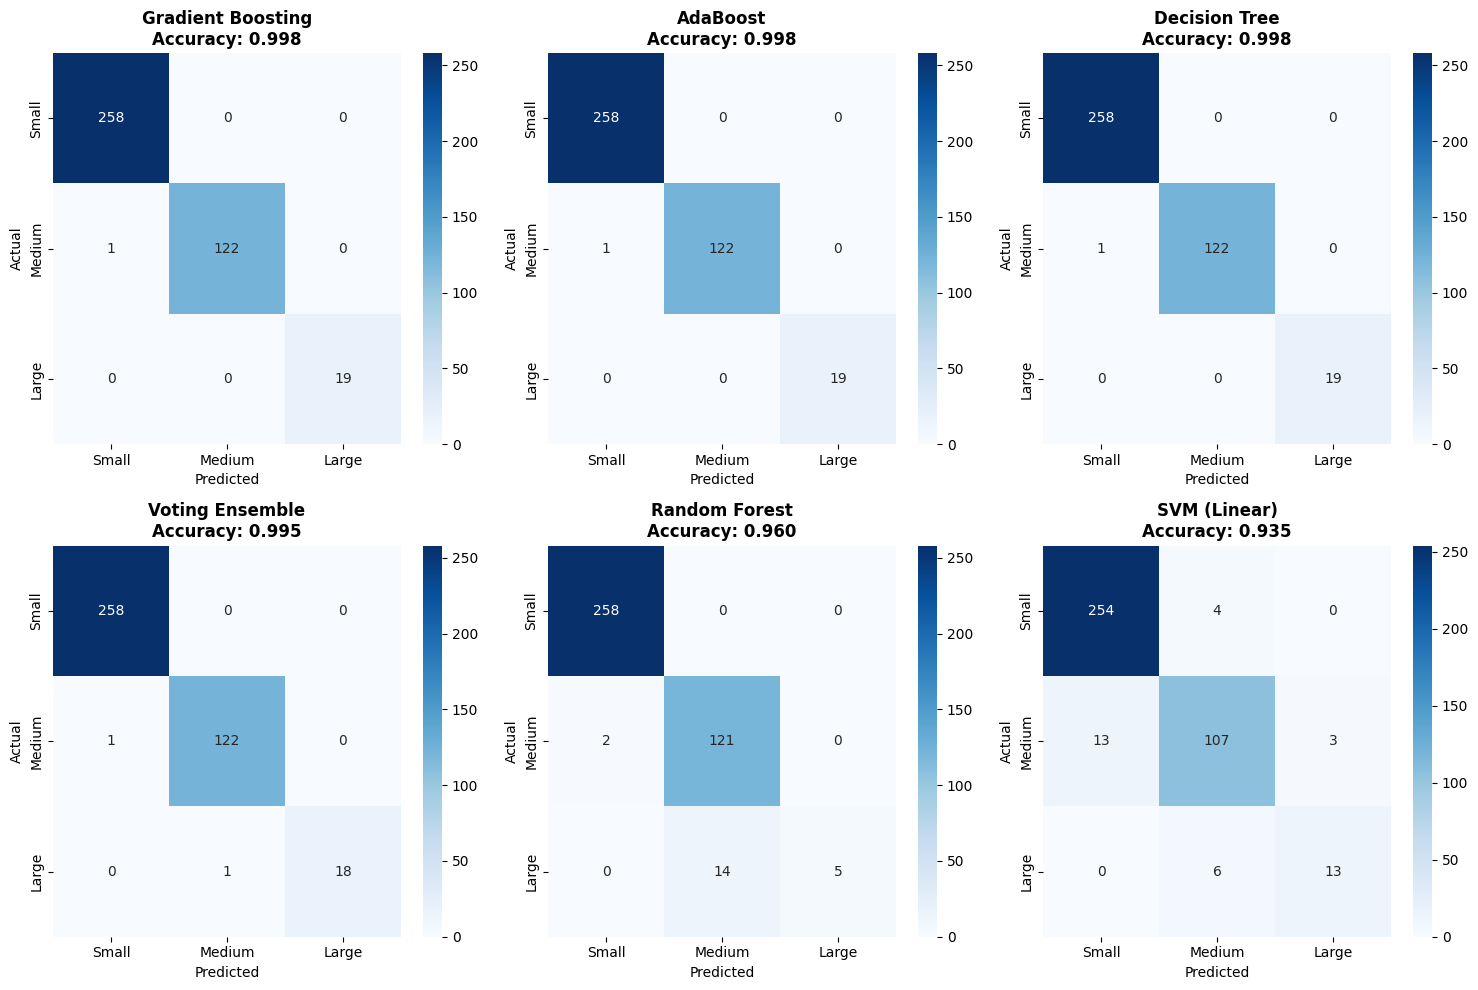

In [19]:
# Plot confusion matrices for top models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

top_models = results_df.nlargest(6, 'Accuracy').index.tolist()

for idx, model_name in enumerate(top_models):
    cm = results[model_name]['Confusion Matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Small', 'Medium', 'Large'],
                yticklabels=['Small', 'Medium', 'Large'])
    axes[idx].set_title(f'{model_name}\nAccuracy: {results[model_name]["Accuracy"]:.3f}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Hide empty subplot if less than 6 models
for idx in range(len(top_models), 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

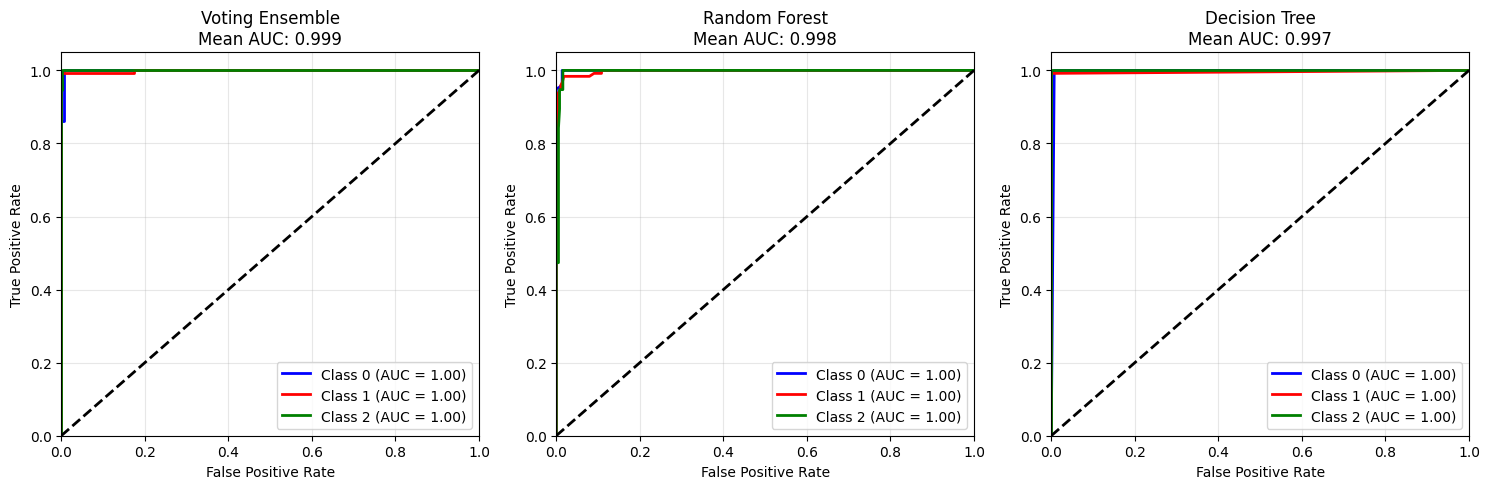

In [20]:
from sklearn.preprocessing import label_binarize

# Binarize labels for ROC curves
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

# Plot ROC curves for top 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
top_3_models = results_df.nlargest(3, 'AUC-ROC').index.tolist()

for idx, model_name in enumerate(top_3_models):
    model = results[model_name]['Model']
    y_score = model.predict_proba(X_test_scaled)
    
    # Compute ROC curve for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot
    colors = ['blue', 'red', 'green']
    for i, color in zip(range(n_classes), colors):
        axes[idx].plot(fpr[i], tpr[i], color=color, lw=2,
                      label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    
    axes[idx].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].set_title(f'{model_name}\nMean AUC: {np.mean(list(roc_auc.values())):.3f}')
    axes[idx].legend(loc="lower right")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

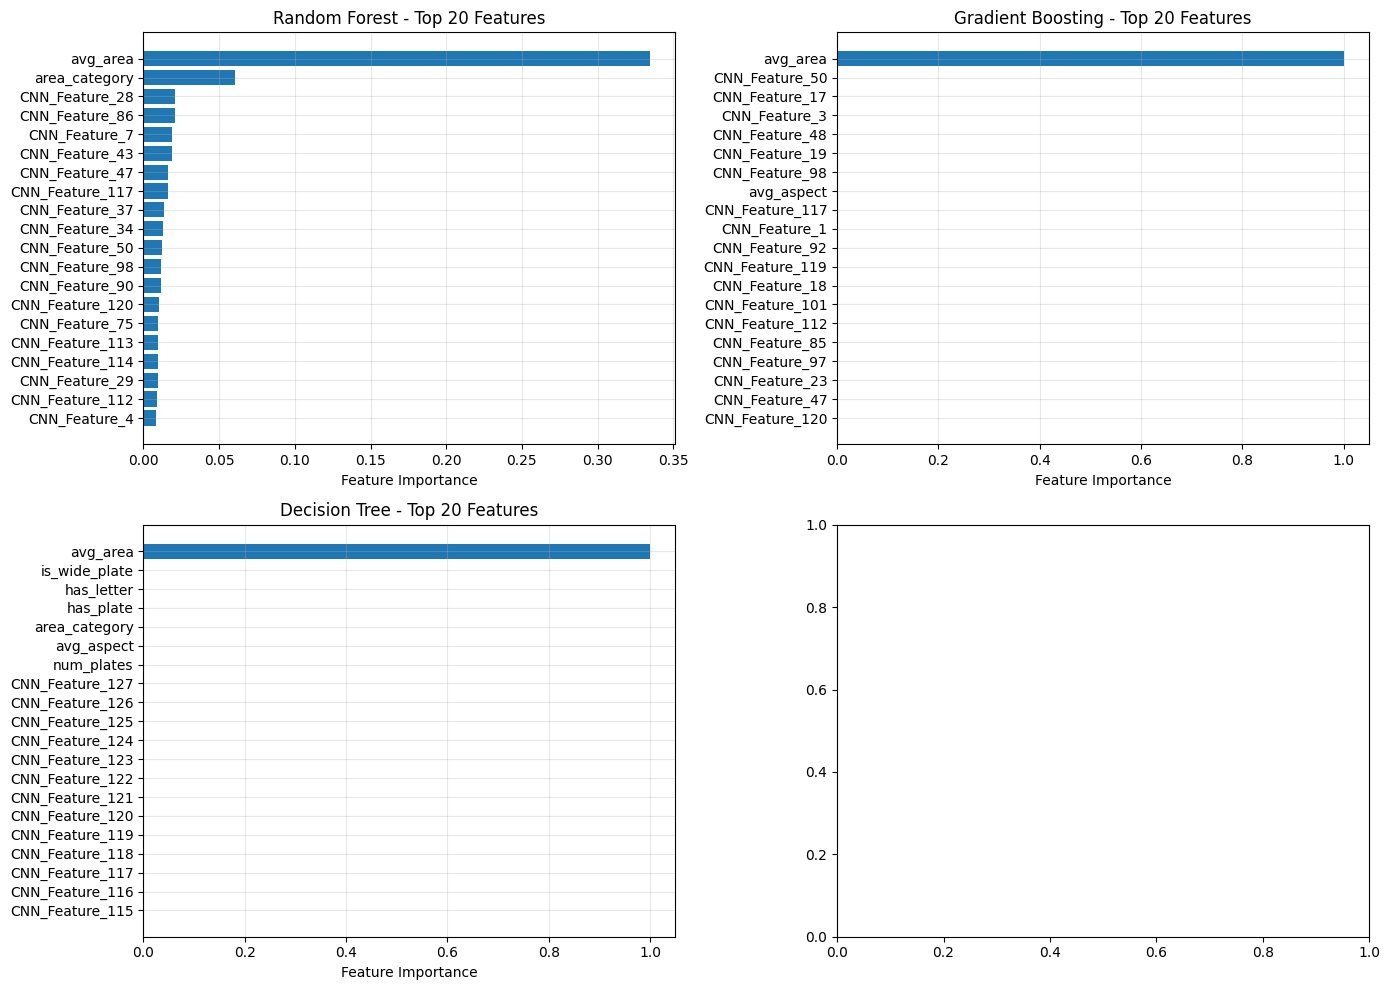

In [21]:
# Analyze feature importance for tree-based models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

tree_models = ['Random Forest', 'Gradient Boosting', 'Decision Tree']
feature_names = [f'CNN_Feature_{i}' for i in range(128)] + \
                ['num_plates', 'avg_area', 'avg_aspect', 'area_category', 'has_plate', 'is_wide_plate', 'has_letter']

for idx, model_name in enumerate(tree_models):
    if model_name in results:
        model = results[model_name]['Model']
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            
            # Get top 20 features
            indices = np.argsort(importances)[-20:]
            
            axes[idx//2, idx%2].barh(range(20), importances[indices])
            axes[idx//2, idx%2].set_yticks(range(20))
            axes[idx//2, idx%2].set_yticklabels([feature_names[i] for i in indices])
            axes[idx//2, idx%2].set_xlabel('Feature Importance')
            axes[idx//2, idx%2].set_title(f'{model_name} - Top 20 Features')
            axes[idx//2, idx%2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
from scipy import stats

# Perform pairwise statistical tests between models
def compare_models_statistically(results_dict, X_test, y_test, n_iterations=30):
    """Compare models using paired t-test and Wilcoxon signed-rank test"""
    
    model_names = list(results_dict.keys())
    n_models = len(model_names)
    
    # Store predictions
    predictions = {}
    for model_name, res in results_dict.items():
        model = res['Model']
        preds = []
        for _ in range(n_iterations):
            # Bootstrap sampling
            indices = np.random.choice(len(X_test), len(X_test), replace=True)
            pred = model.predict(X_test[indices])
            preds.append(accuracy_score(y_test[indices], pred))
        predictions[model_name] = preds
    
    # Create comparison table
    comparison_results = []
    for i in range(n_models):
        for j in range(i+1, n_models):
            model1, model2 = model_names[i], model_names[j]
            
            # Paired t-test
            t_stat, p_value_ttest = stats.ttest_rel(predictions[model1], predictions[model2])
            
            # Wilcoxon signed-rank test
            w_stat, p_value_wilcoxon = stats.wilcoxon(predictions[model1], predictions[model2])
            
            # Mean difference
            mean_diff = np.mean(predictions[model1]) - np.mean(predictions[model2])
            
            comparison_results.append({
                'Model 1': model1,
                'Model 2': model2,
                'Mean Difference': mean_diff,
                'p-value (t-test)': p_value_ttest,
                'p-value (Wilcoxon)': p_value_wilcoxon,
                'Significant (α=0.05)': p_value_ttest < 0.05
            })
    
    return pd.DataFrame(comparison_results)

# Run statistical comparison
stat_results = compare_models_statistically(results, X_test_scaled, y_test)
print("\n📊 Statistical Comparison of Models (Bootstrap with 30 iterations)")
print("="*80)
print(stat_results.to_string(index=False))
print("\n" + "="*80)

# Save results
stat_results.to_csv('statistical_comparison.csv', index=False)


📊 Statistical Comparison of Models (Bootstrap with 30 iterations)
            Model 1             Model 2  Mean Difference  p-value (t-test)  p-value (Wilcoxon)  Significant (α=0.05)
      Random Forest   Gradient Boosting        -0.036833      7.406136e-18            0.000002                  True
      Random Forest            AdaBoost        -0.038083      2.682857e-18            0.000002                  True
      Random Forest           SVM (RBF)         0.136083      2.187017e-26            0.000002                  True
      Random Forest        SVM (Linear)         0.029583      1.684730e-10            0.000003                  True
      Random Forest Logistic Regression         0.022750      1.633506e-08            0.000004                  True
      Random Forest K-Nearest Neighbors         0.208417      9.562943e-30            0.000002                  True
      Random Forest       Decision Tree        -0.038000      1.009022e-18            0.000002                  Tr

In [24]:
# Create formatted results table
styled_results = results_df.copy()
styled_results = styled_results.round(4)

# Add ranking
styled_results['Rank'] = styled_results['Accuracy'].rank(ascending=False).astype(int)

# Reorder columns
styled_results = styled_results[['Rank', 'Accuracy', 'Precision', 'Recall', 'Specificity', 
                                  'F1-Score', 'AUC-ROC', 'Kappa', 'MCC']]

# Sort by rank
styled_results = styled_results.sort_values('Rank')

print("\n" + "="*100)
print("📊 COMPREHENSIVE MODEL COMPARISON RESULTS")
print("="*100)
print(styled_results.to_string())
print("="*100)

# Save to CSV
styled_results.to_csv('model_comparison_results.csv')
print("\n✅ Results saved to 'model_comparison_results.csv'")


📊 COMPREHENSIVE MODEL COMPARISON RESULTS
                     Rank  Accuracy  Precision  Recall  Specificity  F1-Score  AUC-ROC   Kappa     MCC
Gradient Boosting       2    0.9975     0.9975  0.9975       0.9977    0.9975   0.9964  0.9949  0.9949
AdaBoost                2    0.9975     0.9975  0.9975       0.9977    0.9975   0.9964  0.9949  0.9949
Decision Tree           2    0.9975     0.9975  0.9975       0.9977    0.9975   0.9965  0.9949  0.9949
Voting Ensemble         4    0.9950     0.9950  0.9950       0.9964    0.9950   0.9989  0.9897  0.9897
Random Forest           5    0.9600     0.9631  0.9600       0.9785    0.9507   0.9987  0.9160  0.9184
SVM (Linear)            6    0.9350     0.9334  0.9350       0.9548    0.9336   0.9897  0.8639  0.8648
Logistic Regression     7    0.9325     0.9316  0.9325       0.9517    0.9311   0.9837  0.8583  0.8601
SVM (RBF)               8    0.8175     0.8193  0.8175       0.8473    0.8018   0.9253  0.5836  0.6094
K-Nearest Neighbors     9    0.

In [25]:
# Identify best model
best_model_name = styled_results.index[0]
best_model_results = results[best_model_name]
best_accuracy = styled_results.iloc[0]['Accuracy']

print("\n" + "="*100)
print(f"🏆 BEST MODEL: {best_model_name}")
print("="*100)
print(f"📈 Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"📊 Complete Metrics:")
for metric in ['Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC-ROC', 'Kappa', 'MCC']:
    print(f"   - {metric}: {styled_results.iloc[0][metric]:.4f}")

print("\n" + "="*100)
print("📝 INTERPRETATION AND INSIGHTS")
print("="*100)

# Generate insights
insights = []

# Best performing architecture
insights.append(f"• Best CNN Architecture: {best_architecture}")

# Model type analysis
model_types = {
    'Ensemble': ['Voting Ensemble', 'Random Forest', 'Gradient Boosting', 'AdaBoost'],
    'SVM': ['SVM (RBF)', 'SVM (Linear)'],
    'Linear': ['Logistic Regression'],
    'Distance-based': ['K-Nearest Neighbors'],
    'Tree-based': ['Decision Tree'],
    'Probabilistic': ['Naive Bayes']
}

best_model_type = [k for k, v in model_types.items() if best_model_name in v]
if best_model_type:
    insights.append(f"• Best Model Type: {best_model_type[0]}")

# Performance analysis
if styled_results.iloc[0]['AUC-ROC'] > 0.9:
    insights.append("• Excellent discriminative ability (AUC-ROC > 0.90)")
elif styled_results.iloc[0]['AUC-ROC'] > 0.8:
    insights.append("• Good discriminative ability (AUC-ROC > 0.80)")

if styled_results.iloc[0]['Kappa'] > 0.8:
    insights.append("• Almost perfect agreement (Kappa > 0.80)")
elif styled_results.iloc[0]['Kappa'] > 0.6:
    insights.append("• Substantial agreement (Kappa > 0.60)")

# Feature engineering impact
if 'num_plates' in feature_names and any('num_plates' in str(idx) for idx in range(20)):
    insights.append("• Engineering features contributed significantly to model performance")

for insight in insights:
    print(insight)

print("\n" + "="*100)


🏆 BEST MODEL: Gradient Boosting
📈 Accuracy: 0.9975 (99.75%)
📊 Complete Metrics:
   - Precision: 0.9975
   - Recall: 0.9975
   - Specificity: 0.9977
   - F1-Score: 0.9975
   - AUC-ROC: 0.9964
   - Kappa: 0.9949
   - MCC: 0.9949

📝 INTERPRETATION AND INSIGHTS
• Best CNN Architecture: VGG16
• Best Model Type: Ensemble
• Excellent discriminative ability (AUC-ROC > 0.90)
• Almost perfect agreement (Kappa > 0.80)



In [26]:
import joblib

# Save best model and scaler
best_model_object = results[best_model_name]['Model']
joblib.dump(best_model_object, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"✅ Best model ({best_model_name}) saved as 'best_model.pkl'")
print(f"✅ Scaler saved as 'scaler.pkl'")

# Save all results
all_results = {
    'model_comparison': styled_results.to_dict(),
    'statistical_tests': stat_results.to_dict(),
    'best_model': best_model_name,
    'best_architecture': best_architecture,
    'feature_names': feature_names
}

import json
with open('all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print("✅ All results saved to 'all_results.json'")

✅ Best model (Gradient Boosting) saved as 'best_model.pkl'
✅ Scaler saved as 'scaler.pkl'
✅ All results saved to 'all_results.json'


In [28]:
# Create comprehensive dashboard
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=('Accuracy Comparison', 'AUC-ROC Scores', 'Precision-Recall',
                    'Model Ranking', 'Performance Distribution', 'Top Features'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}, {'type': 'scatter'}],
           [{'type': 'bar'}, {'type': 'box'}, {'type': 'bar'}]]
)

# 1. Accuracy comparison
fig.add_trace(go.Bar(x=styled_results.index, y=styled_results['Accuracy'], 
                     text=styled_results['Accuracy'].round(3), textposition='auto',
                     marker_color='lightblue', name='Accuracy'),
              row=1, col=1)

# 2. AUC-ROC comparison
fig.add_trace(go.Bar(x=styled_results.index, y=styled_results['AUC-ROC'],
                     text=styled_results['AUC-ROC'].round(3), textposition='auto',
                     marker_color='lightgreen', name='AUC-ROC'),
              row=1, col=2)

# 3. Precision vs Recall scatter
fig.add_trace(go.Scatter(x=styled_results['Precision'], y=styled_results['Recall'],
                         mode='markers+text', text=styled_results.index,
                         textposition="top center",
                         marker=dict(size=15, color=styled_results['F1-Score'], 
                                   colorscale='Viridis', showscale=True),
                         name='Precision-Recall'),
              row=1, col=3)

# 4. Model ranking
fig.add_trace(go.Bar(x=styled_results['Rank'], y=styled_results.index,
                     orientation='h', marker_color='coral',
                     name='Ranking'),
              row=2, col=1)

# 5. Performance distribution box plots
for model in styled_results.index[:5]:  # Top 5 models
    cv_scores_model = cross_val_score(results[model]['Model'], X_train_scaled, y_train, cv=5)
    fig.add_trace(go.Box(y=cv_scores_model, name=model, boxmean='sd'),
                  row=2, col=2)

# 6. Feature importance for best model
if hasattr(best_model_object, 'feature_importances_'):
    importances = best_model_object.feature_importances_
    top_indices = np.argsort(importances)[-10:]
    top_features = [feature_names[i] for i in top_indices]
    top_importances = importances[top_indices]
    
    fig.add_trace(go.Bar(x=top_features, y=top_importances, 
                         marker_color='salmon', name='Top Features'),
                  row=2, col=3)

fig.update_layout(height=800, width=1200, title_text="Egyptian Plate Detection - Complete Model Analysis Dashboard",
                  showlegend=True, font=dict(size=10))
fig.update_xaxes(tickangle=45)
fig.show()

# Save dashboard as HTML
fig.write_html("model_analysis_dashboard.html")
print("✅ Interactive dashboard saved as 'model_analysis_dashboard.html'")

✅ Interactive dashboard saved as 'model_analysis_dashboard.html'
